# Sistema de Encriptación de Imágenes RGB con Lógica Cuántica — Qiskit

Conversión del código MATLAB original al ecosistema Python + Qiskit.

**Pipeline de encriptación:**
1. Permutación intra-bit por planos (caos de Chen, RK4)
2. Autómatas celulares compuestos (reglas derivadas del atractor de Chen)
3. Difusión caótica cuántica — Sumador de Draper (QFT) con puertas Hadamard + rotaciones de fase

**Dependencias:**
```
pip install qiskit qiskit-aer numpy matplotlib pillow scipy
```

Autores: Marlon Riveros — conversión Python/Qiskit


In [5]:
%pip install qiskit qiskit-aer numpy matplotlib pillow scipy

Note: you may need to restart the kernel to use updated packages.


## Configuración global e imports

In [6]:
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from PIL import Image

# ── Qiskit ────────────────────────────────────────────────────────────────────
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

# ─────────────────────────────────────────────────────────────────────────────
#  CONFIGURACIÓN GLOBAL
# ─────────────────────────────────────────────────────────────────────────────
IMG_PATH = "C:/Users/USER/Downloads/Peppers.jpg"   # <-- cambia la ruta a tu imagen

# ─────────────────────────────────────────────────────────────────────────────
#  SIMULADOR QISKIT (singleton, se inicializa una vez)
# ─────────────────────────────────────────────────────────────────────────────
_simulator = AerSimulator(method='matrix_product_state')

## Sección 1 — Secuencia caótica de Chen (RK4)

In [7]:
def _chen_f(x, y, z, a=35, b=3, c=28):
    """Ecuaciones diferenciales del sistema de Chen."""
    return np.array([a * (y - x),
                     (c - a) * x - x * z + c * y,
                     x * y - b * z])


def _rk4_step(x, y, z, dt=0.001, a=35, b=3, c=28):
    """Un paso RK4 para el sistema de Chen."""
    state = np.array([x, y, z])
    k1 = _chen_f(*state, a, b, c)
    k2 = _chen_f(*(state + dt / 2 * k1), a, b, c)
    k3 = _chen_f(*(state + dt / 2 * k2), a, b, c)
    k4 = _chen_f(*(state + dt * k3), a, b, c)
    new = state + dt * (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return new[0], new[1], new[2]


def chen_sequence(x0, y0, z0, N0, N, dt=0.001):
    """
    Genera N valores normalizados [0,1] del atractor de Chen.
    N0 = iteraciones de calentamiento (transiente).
    Devuelve (Sx, Sy, Sz) arrays de longitud N.
    """
    x, y, z = x0, y0, z0
    for _ in range(N0):
        x, y, z = _rk4_step(x, y, z, dt)

    raw_x = np.empty(N)
    raw_y = np.empty(N)
    raw_z = np.empty(N)
    for k in range(N):
        x, y, z = _rk4_step(x, y, z, dt)
        raw_x[k], raw_y[k], raw_z[k] = x, y, z

    def norm(v):
        mn, mx = v.min(), v.max()
        return (v - mn) / (mx - mn + np.finfo(float).eps)

    return norm(raw_x), norm(raw_y), norm(raw_z)

## Sección 2 — Permutación intra-bit

In [8]:
def get_permutation_from_chaos(S):
    """Permutación por orden ascendente de la secuencia caótica S."""
    return np.argsort(S, kind='stable')


def intra_bit_permutation(bp, S_channel):
    """
    Permuta los píxeles de un plano de bits usando la secuencia caótica.
    bp     : array 2D bool (filas x columnas)
    Retorna (bp_perm, Gmask, perm)
    """
    rows, cols = bp.shape
    perm = get_permutation_from_chaos(S_channel)
    vector = bp.ravel().copy()
    vector_perm = vector[perm]
    bp_perm = vector_perm.reshape(rows, cols)
    Gmask = np.logical_xor(bp, bp_perm)
    return bp_perm, Gmask, perm


def inverse_intra_bit_permutation(bp_perm, perm):
    """Invierte la permutación intra-bit."""
    rows, cols = bp_perm.shape
    inv_perm = np.empty_like(perm)
    inv_perm[perm] = np.arange(len(perm))
    vector = bp_perm.ravel()
    return vector[inv_perm].reshape(rows, cols)

## Sección 3 — Autómatas celulares

In [9]:
_COMPOSITE_RULES = {
    0:  {'enc': 'AAAaaAaa', 'dec': 'CCccCccC'},
    1:  {'enc': 'AaaAaaAA', 'dec': 'ccCccCCC'},
    2:  {'enc': 'aAaaAAAa', 'dec': 'CccCCCcc'},
    3:  {'enc': 'aaAAAaaA', 'dec': 'cCCCccCc'},
    4:  {'enc': 'CCcCCccc', 'dec': 'aAAaAAaa'},
    5:  {'enc': 'ccCCcCCc', 'dec': 'aaaAAaAA'},
    6:  {'enc': 'CcccCCcC', 'dec': 'AAaaaAAa'},
    7:  {'enc': 'cCCcccCC', 'dec': 'AaAAaaaA'},
    8:  {'enc': 'BBbBCaca', 'dec': 'BBbBcAca'},
    9:  {'enc': 'bcABcABb', 'dec': 'bCaBCaBb'},
    10: {'enc': 'CabbBCaB', 'dec': 'cAbbBcAB'},
    11: {'enc': 'bBCabbCA', 'dec': 'bBcAbbCA'},
    12: {'enc': 'bcACAbbB', 'dec': 'bCaCAbbB'},
    13: {'enc': 'bBbcACAb', 'dec': 'bBbCaCAb'},
    14: {'enc': 'CABcaBbb', 'dec': 'CABcaBbb'},
    15: {'enc': 'BbcAbcAB', 'dec': 'BbCabCaB'},
}


def _apply_symbol(L, S, R, sym):
    """Aplica un símbolo de la regla compuesta al vecindario (L, S, R)."""
    if   sym == 'A': return L
    elif sym == 'B': return S
    elif sym == 'C': return R
    elif sym == 'a': return 1 - L
    elif sym == 'b': return 1 - S
    elif sym == 'c': return 1 - R
    else:
        raise ValueError(f"Símbolo inválido: {sym}")


def _evolve_once(state, rule_str):
    """Evoluciona un buffer de 8 bits según una regla compuesta."""
    n = len(state)
    ns = np.zeros(n, dtype=np.uint8)
    for i in range(n):
        L = state[(i - 1) % n]
        S = state[i]
        R = state[(i + 1) % n]
        ns[i] = _apply_symbol(L, S, R, rule_str[i])
    return ns


def _process_buffer(buf, rule_str):
    """Procesa el buffer completo en bloques de 8."""
    L = len(buf)
    num_blocks = L // 8
    original = buf.copy()
    for b in range(num_blocks):
        i0 = b * 8
        idxs = np.mod(np.arange(i0, i0 + 8), L)
        buf[idxs] = _evolve_once(original[idxs], rule_str)
    return buf


def _apply_automaton_by_lines(M, rule_str, times, path_type):
    """Aplica el autómata celular a la matriz M según el recorrido indicado."""
    R, C = M.shape
    for _ in range(times):
        if path_type == 'col_up_lr':
            buf = np.zeros(R * C, dtype=np.uint8)
            pos = 0
            for j in range(C):
                buf[pos:pos + R] = M[R - 1::-1, j]
                pos += R
            buf = _process_buffer(buf, rule_str)
            pos = 0
            for j in range(C):
                M[R - 1::-1, j] = buf[pos:pos + R]
                pos += R
        elif path_type == 'row_lr':
            buf = np.zeros(R * C, dtype=np.uint8)
            pos = 0
            for i in range(R):
                buf[pos:pos + C] = M[i, :]
                pos += C
            buf = _process_buffer(buf, rule_str)
            pos = 0
            for i in range(R):
                M[i, :] = buf[pos:pos + C]
                pos += C
        elif path_type == 'col_up_rl':
            buf = np.zeros(R * C, dtype=np.uint8)
            pos = 0
            for j in range(C - 1, -1, -1):
                buf[pos:pos + R] = M[R - 1::-1, j]
                pos += R
            buf = _process_buffer(buf, rule_str)
            pos = 0
            for j in range(C - 1, -1, -1):
                M[R - 1::-1, j] = buf[pos:pos + R]
                pos += R
    return M


def _derive_automata_and_iterations(vals):
    """
    Extrae id de autómata (0-15) e iteraciones a partir de
    valores caóticos flotantes (igual que en MATLAB).
    """
    automatas = np.zeros(len(vals), dtype=int)
    iteraciones = np.zeros(len(vals), dtype=int)
    for i, v in enumerate(vals):
        v = abs(v)
        frac = v - int(v)
        automatas[i] = int(frac * 1000) % 16
        d1 = int(frac * 10)
        d2 = int(frac * 100) - d1 * 10
        d3 = int(frac * 1000) - int(frac * 100) * 10
        if   d3 != 0: iteraciones[i] = d3
        elif d2 != 0: iteraciones[i] = d2
        elif d1 != 0: iteraciones[i] = d1
        else:         iteraciones[i] = 1
    return automatas, iteraciones


def cellular_automaton_encryption(channel, x0, y0, z0, N0, encrypt=True, verbose=False):
    """
    Cifrado / descifrado por autómatas celulares compuestos.
    channel : array 2D uint8
    encrypt : True = cifrar, False = descifrar
    """
    rows, cols = channel.shape
    raw_x, raw_y, raw_z = _chen_raw_ca(x0, y0, z0, N0, 3)
    chaos_vals = [raw_x[0], raw_y[0], raw_z[0]]
    automatas, iteraciones = _derive_automata_and_iterations(chaos_vals)

    if verbose:
        print(f"  [CA] x={chaos_vals[0]:.10f}  y={chaos_vals[1]:.10f}  z={chaos_vals[2]:.10f}")
        print(f"  [CA] Autómatas: {automatas}  |  Iteraciones: {iteraciones}")

    recorridos = ['col_up_lr', 'row_lr', 'col_up_rl']
    channel_out = np.zeros((rows, cols), dtype=np.uint8)

    for k in range(8):          # k=0 → bit MSB (posición 7), k=7 → bit LSB (posición 0)
        bit_pos = 7 - k          # numpy: bit 7 = MSB
        bp = ((channel >> bit_pos) & 1).astype(np.uint8)

        apply_order = range(3) if encrypt else range(2, -1, -1)
        for idx in apply_order:
            aid  = automatas[idx]
            t    = iteraciones[idx]
            rule = _COMPOSITE_RULES[aid]['enc' if encrypt else 'dec']
            bp   = _apply_automaton_by_lines(bp, rule, t, recorridos[idx])

        channel_out = channel_out | (bp.astype(np.uint8) << bit_pos)

    return channel_out


def _chen_raw_ca(x0, y0, z0, N0, N, dt=0.001):
    """Genera N valores *sin normalizar* del sistema de Chen (para CA)."""
    x, y, z = x0, y0, z0
    for _ in range(N0):
        x, y, z = _rk4_step(x, y, z, dt)
    raw_x = np.empty(N)
    raw_y = np.empty(N)
    raw_z = np.empty(N)
    for k in range(N):
        x, y, z = _rk4_step(x, y, z, dt)
        raw_x[k], raw_y[k], raw_z[k] = x, y, z
    return raw_x, raw_y, raw_z

## Sección 4 — Difusión caótica cuántica — Sumador de Draper (QFT)

**Fundamento matemático — Sumador de Draper (arXiv:quant-ph/0008033)**

El Draper Adder realiza la suma completamente dentro del circuito cuántico
sin bits de acarreo auxiliares, usando la QFT como espacio de trabajo:

```
|a⟩|b⟩  ─[QFT en b]→  |a⟩|QFT(b)⟩
          ─[rotaciones CP controladas por a]→  |a⟩|QFT(a+b)⟩
          ─[QFT† en b]→  |a⟩|(a+b) mod 2ⁿ⟩
```

La suma `(P + K + C_prev) mod 256` usa tres sumadores de Draper encadenados
sobre un acumulador de 8 qubits:

```
acc = 0  →[Draper]→  acc+P  →[Draper]→  acc+P+K  →[Draper]→  P+K+C mod 256
```

**Puertas cuánticas activas:**
- `H` (Hadamard) — lleva cada qubit al dominio de fases (QFT)
- `CP` (Phase controlada) — rotaciones fraccionales e^{2πi/2^k}
- `SWAP` — invierte orden big-endian al final de la QFT
- `CNOT` — XOR cuántico para la operación `temp ⊕ K`
- `X` (Pauli-X) — inicialización de estados clásicos a |0⟩/|1⟩

Tamaño del circuito por píxel: **32 qubits** (4 registros × 8)


In [10]:
import math

# n = número de qubits por registro (8 bits = 1 byte)
_N_QUBITS = 8


def _qft_n(qc: QuantumCircuit, q: list):
    """
    Transformada Cuántica de Fourier (QFT) con convención LSB-first.

    q[0] es el qubit LSB (peso 2⁰) antes y después de la QFT.
    Aplica H + rotaciones CP de mayor a menor índice, luego SWAPs
    para invertir el orden y mantener la convención LSB-first.

    Puertas activas: H, CP(2π/2^k), SWAP.
    """
    n = len(q)
    for i in range(n - 1, -1, -1):
        qc.h(q[i])
        for j in range(i - 1, -1, -1):
            qc.cp(2 * math.pi / (2 ** (i - j + 1)), q[j], q[i])
    for i in range(n // 2):
        qc.swap(q[i], q[n - 1 - i])


def _iqft_n(qc: QuantumCircuit, q: list):
    """
    QFT† (QFT inversa) — invierte _qft_n exactamente.

    Deshace primero los SWAPs y luego aplica rotaciones CP negadas + H
    en orden inverso.
    """
    n = len(q)
    for i in range(n // 2):
        qc.swap(q[i], q[n - 1 - i])
    for i in range(n):
        for j in range(i - 1, -1, -1):
            qc.cp(-2 * math.pi / (2 ** (i - j + 1)), q[j], q[i])
        qc.h(q[i])


def _phi_add(qc: QuantumCircuit, qa: list, qb: list):
    """
    Suma en el dominio de fases (fase-kickback de Draper).

    Precondición: qb debe estar en el dominio QFT (|QFT(b)⟩).
    Postcondición: qb queda en |QFT(a+b)⟩.

    Para cada par (l, j) con l+j < n aplica:
        CP(2π / 2^(n-l-j),  qa[l],  qb[j])
    lo que acumula la fase de 'a' sobre el registro 'b' en el espacio
    de Fourier, equivalente a sumar 'a' cuando se aplique QFT†.

    Puertas activas: CP (fase controlada) — ninguna H ni SWAP.
    """
    n = len(qb)
    for j in range(n):
        for l in range(n):
            if l + j < n:
                qc.cp(2 * math.pi / (2 ** (n - l - j)), qa[l], qb[j])


def _build_draper_sum3_circuit(val_p: int, val_k: int, val_c: int) -> QuantumCircuit:
    """
    Circuito cuántico que calcula  result = (P + K + C_prev) mod 256
    mediante TRES sumadores de Draper (QFT) encadenados sobre un acumulador.

    Registros (n=8 qubits cada uno, total 32 qubits):
      qr_p   : |P⟩    — byte del píxel actual           (solo lectura)
      qr_k   : |K⟩    — byte de clave caótica           (solo lectura)
      qr_c   : |C⟩    — byte del píxel cifrado anterior (solo lectura)
      qr_acc : |0⟩    — acumulador; recibirá P+K+C mod 256
      cr     : 8 bits — resultado medido

    Flujo del circuito:
      Puertas X  → inicializar |P⟩, |K⟩, |C⟩ con los valores clásicos
      Draper 1:  QFT(acc) → φ_add(P, acc) → QFT†(acc)   ⟹  acc = P
      Draper 2:  QFT(acc) → φ_add(K, acc) → QFT†(acc)   ⟹  acc = P+K
      Draper 3:  QFT(acc) → φ_add(C, acc) → QFT†(acc)   ⟹  acc = P+K+C mod 256
      Measure    → colapsar qr_acc al resultado clásico

    Puertas cuánticas reales activas por circuito:
      3 × (8H + 28CP_QFT + 4SWAP)  [QFT/QFT†]
      3 × (hasta 36 CP_φ)           [phi_add]
      hasta 24 X                    [inicialización]
    Qubits totales: 32 (4 registros × 8)
    Simulador requerido: MPS (matrix_product_state) — statevector
    necesita 65536 MB para 32 qubits.
    """
    n = _N_QUBITS
    qr_p   = QuantumRegister(n, name='P')
    qr_k   = QuantumRegister(n, name='K')
    qr_c   = QuantumRegister(n, name='Cprev')
    qr_acc = QuantumRegister(n, name='acc')
    cr     = ClassicalRegister(n, name='out')
    qc     = QuantumCircuit(qr_p, qr_k, qr_c, qr_acc, cr)

    for i in range(n):
        if (val_p >> i) & 1: qc.x(qr_p[i])
        if (val_k >> i) & 1: qc.x(qr_k[i])
        if (val_c >> i) & 1: qc.x(qr_c[i])

    _qft_n(qc, list(qr_acc))
    _phi_add(qc, list(qr_p), list(qr_acc))
    _iqft_n(qc, list(qr_acc))

    _qft_n(qc, list(qr_acc))
    _phi_add(qc, list(qr_k), list(qr_acc))
    _iqft_n(qc, list(qr_acc))

    _qft_n(qc, list(qr_acc))
    _phi_add(qc, list(qr_c), list(qr_acc))
    _iqft_n(qc, list(qr_acc))

    qc.measure(qr_acc, cr)
    return qc


def _build_xor_circuit(byte_p: int, byte_k: int) -> QuantumCircuit:
    """
    Circuito XOR cuántico:  |P⟩|K⟩  →  |P ⊕ K⟩
    Implementado bit a bit con puertas CNOT (qr_k[i] controla qr_p[i]).
    """
    qr_p = QuantumRegister(8, name='p')
    qr_k = QuantumRegister(8, name='k')
    cr   = ClassicalRegister(8, name='c')
    qc   = QuantumCircuit(qr_p, qr_k, cr)
    for i in range(8):
        if (byte_p >> i) & 1:
            qc.x(qr_p[i])
    for i in range(8):
        if (byte_k >> i) & 1:
            qc.x(qr_k[i])
    for i in range(8):
        qc.cx(qr_k[i], qr_p[i])   # p[i] ← p[i] ⊕ k[i]
    qc.measure(qr_p, cr)
    return qc


def _run_circuit(qc: QuantumCircuit) -> int:
    """Ejecuta un circuito determinista y devuelve el resultado como entero."""
    job    = _simulator.run(qc, shots=1, memory=True)
    bitstr = job.result().get_memory()[0]
    return int(bitstr, 2)


def _quantum_sum3(val_p: int, val_k: int, val_c: int) -> int:
    """
    Calcula (P + K + C_prev) mod 256 completamente dentro del circuito
    cuántico de Draper (32 qubits, puertas H + CP + SWAP + X).
    """
    qc = _build_draper_sum3_circuit(val_p, val_k, val_c)
    return _run_circuit(qc)


def _quantum_xor(byte_p: int, byte_k: int) -> int:
    """Calcula byte_p XOR byte_k mediante puertas CNOT."""
    qc = _build_xor_circuit(byte_p, byte_k)
    return _run_circuit(qc)


def chaotic_diffusion_quantum(img_channel: np.ndarray,
                              S_channel: np.ndarray) -> np.ndarray:
    """
    Difusión caótica cuántica AUTÉNTICA usando el sumador de Draper (QFT).

    La suma  (P[i] + K[i] + C[i-1]) mod 256  ocurre COMPLETAMENTE dentro
    del circuito cuántico mediante tres sumadores de Draper encadenados.
    El XOR final  temp ⊕ K[i-1]  se ejecuta con puertas CNOT.

    Puertas activas por píxel:
      3 × Draper (H, CP, SWAP)  +  CNOT (XOR)  +  X (inicialización)
    Qubits por circuito: 32  (4 registros × 8)
    """
    rows, cols = img_channel.shape
    N = rows * cols

    P = img_channel.ravel().astype(np.int32)
    K = (np.floor(np.abs(S_channel.ravel()) * 1e14) % 256).astype(np.int32)

    C = np.zeros(N, dtype=np.int32)

    C[0] = _quantum_xor(int(P[0]), int(K[0]))

    for i in range(1, N):
        temp = _quantum_sum3(int(P[i]), int(K[i]), int(C[i - 1]))
        C[i] = _quantum_xor(temp, int(K[i - 1]))

    for i in range(N - 2, -1, -1):
        temp = _quantum_sum3(int(C[i]), int(C[i + 1]), int(K[i]))
        C[i] = _quantum_xor(temp, int(K[i + 1]))

    return C.astype(np.uint8).reshape(rows, cols)


def inverse_quantum_diffusion(img_cipher: np.ndarray,
                               S_channel: np.ndarray) -> np.ndarray:
    """
    Invierte la difusión cuántica de Draper.

    El XOR se invierte con otro XOR (CNOT es su propio inverso: a ⊕ b ⊕ b = a).
    La resta  (a - b - c) mod 256  se implementa como suma del complemento
    a dos dentro del circuito de Draper:
        a - b - c  ≡  a + (256-b) + (256-c)  (mod 256)
    Esto permite usar el mismo sumador cuántico tanto en cifrado como descifrado.
    """
    rows, cols = img_cipher.shape
    N = rows * cols

    C = img_cipher.ravel().astype(np.int32)
    K = (np.floor(np.abs(S_channel.ravel()) * 1e14) % 256).astype(np.int32)

    for i in range(N - 1):
        temp = _quantum_xor(int(C[i]), int(K[i + 1]))
        C[i] = _quantum_sum3(temp,
                             int((256 - C[i + 1]) % 256),
                             int((256 - K[i])     % 256))

    P = np.zeros(N, dtype=np.int32)
    P[0] = _quantum_xor(int(C[0]), int(K[0]))

    for i in range(1, N):
        temp = _quantum_xor(int(C[i]), int(K[i - 1]))
        P[i] = _quantum_sum3(temp,
                             int((256 - K[i])     % 256),
                             int((256 - C[i - 1]) % 256))

    return P.astype(np.uint8).reshape(rows, cols)

## Sección 5 — Análisis de seguridad (funciones auxiliares)

In [11]:
def shannon_entropy(v: np.ndarray) -> float:
    """Entropía de Shannon en bits."""
    counts = np.bincount(v.ravel().astype(np.uint8), minlength=256).astype(float)
    p = counts / counts.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))


def calcular_npcr_uaci(img1: np.ndarray, img2: np.ndarray):
    """NPCR y UACI entre dos imágenes (canal único o RGB)."""
    D = (img1.astype(float) != img2.astype(float))
    npcr = 100.0 * D.sum() / D.size
    uaci = 100.0 * np.abs(img1.astype(float) - img2.astype(float)).sum() / (255.0 * img1.size)
    return npcr, uaci


def extraer_pares(canal: np.ndarray, n_muestra: int):
    """Extrae pares de píxeles adyacentes (horizontal, vertical, diagonal)."""
    F, C = canal.shape
    rng = np.random.default_rng(42)

    xi = canal[:F, :C - 1]; yi = canal[:F, 1:C]
    idx = rng.choice(xi.size, min(n_muestra, xi.size), replace=False)
    rH, cH = xi.ravel()[idx].astype(float), yi.ravel()[idx].astype(float)

    xi = canal[:F - 1, :C]; yi = canal[1:F, :C]
    idx = rng.choice(xi.size, min(n_muestra, xi.size), replace=False)
    rV, cV = xi.ravel()[idx].astype(float), yi.ravel()[idx].astype(float)

    xi = canal[:F - 1, :C - 1]; yi = canal[1:F, 1:C]
    idx = rng.choice(xi.size, min(n_muestra, xi.size), replace=False)
    rD, cD = xi.ravel()[idx].astype(float), yi.ravel()[idx].astype(float)

    return rH, cH, rV, cV, rD, cD


def pearson_r(a, b):
    if np.std(a) == 0 or np.std(b) == 0:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

## Sección 6 — Pipeline completo de encriptación

In [12]:
def encrypt_image(img_path: str):
    """
    Ejecuta el pipeline completo de encriptación sobre una imagen RGB.
    Devuelve un diccionario con todos los resultados intermedios y finales.
    """
    t0 = time.time()

    img_pil  = Image.open(img_path).convert('RGB')
    img      = np.array(img_pil, dtype=np.uint8)
    rojo     = img[:, :, 0]
    verde    = img[:, :, 1]
    azul     = img[:, :, 2]
    filas, columnas = img.shape[:2]
    N_pixel  = filas * columnas

    x0_key  = -0.2;  y0_key  = 0.4;  z0_key  = 0.7
    N0_chen = 1000
    x0_ca   = x0_key + 0.333
    y0_ca   = y0_key - 0.111
    z0_ca   = z0_key + 0.777
    N0_ca   = 500

    rojo_bin  = np.zeros((filas, columnas, 8), dtype=bool)
    verde_bin = np.zeros((filas, columnas, 8), dtype=bool)
    azul_bin  = np.zeros((filas, columnas, 8), dtype=bool)
    for k in range(8):
        bit_pos = 7 - k
        rojo_bin[:, :, k]  = (rojo  >> bit_pos) & 1
        verde_bin[:, :, k] = (verde >> bit_pos) & 1
        azul_bin[:, :, k]  = (azul  >> bit_pos) & 1

    rojo_perm  = np.zeros_like(rojo_bin)
    verde_perm = np.zeros_like(verde_bin)
    azul_perm  = np.zeros_like(azul_bin)

    for k in range(8):
        z0_k = z0_key + k * 1e-4
        Sx_k, Sy_k, Sz_k = chen_sequence(x0_key, y0_key, z0_k, N0_chen, N_pixel)
        rojo_perm[:, :, k],  _, _ = intra_bit_permutation(rojo_bin[:, :, k],  Sx_k)
        verde_perm[:, :, k], _, _ = intra_bit_permutation(verde_bin[:, :, k], Sy_k)
        azul_perm[:, :, k],  _, _ = intra_bit_permutation(azul_bin[:, :, k],  Sz_k)

    R_rec = np.zeros((filas, columnas), dtype=np.uint8)
    G_rec = np.zeros((filas, columnas), dtype=np.uint8)
    B_rec = np.zeros((filas, columnas), dtype=np.uint8)
    for k in range(8):
        bit_pos = 7 - k
        R_rec |= rojo_perm[:, :, k].astype(np.uint8)  << bit_pos
        G_rec |= verde_perm[:, :, k].astype(np.uint8) << bit_pos
        B_rec |= azul_perm[:, :, k].astype(np.uint8)  << bit_pos

    print("  [CA] Aplicando autómatas celulares...")
    R_ca = cellular_automaton_encryption(R_rec, x0_ca, y0_ca, z0_ca,       N0_ca, encrypt=True)
    G_ca = cellular_automaton_encryption(G_rec, x0_ca, y0_ca, z0_ca + 0.1, N0_ca, encrypt=True)
    B_ca = cellular_automaton_encryption(B_rec, x0_ca, y0_ca, z0_ca + 0.2, N0_ca, encrypt=True)

    print("  [QC] Generando secuencias caóticas para difusión...")
    Sx_diff, Sy_diff, Sz_diff = chen_sequence(x0_key, y0_key, z0_key + 0.1, N0_chen, N_pixel)

    print("  [QC] Aplicando difusión cuántica (Qiskit) — canal R...")
    R_cifrado = chaotic_diffusion_quantum(R_ca, Sx_diff)
    print("  [QC] Aplicando difusión cuántica (Qiskit) — canal G...")
    G_cifrado = chaotic_diffusion_quantum(G_ca, Sy_diff)
    print("  [QC] Aplicando difusión cuántica (Qiskit) — canal B...")
    B_cifrado = chaotic_diffusion_quantum(B_ca, Sz_diff)

    img_cifrada = np.stack([R_cifrado, G_cifrado, B_cifrado], axis=2)

    tf = time.time() - t0
    print(f"\n  Tiempo de encriptación: {tf:.2f} s")

    return {
        'img_original'  : img,
        'img_cifrada'   : img_cifrada,
        'rojo'          : rojo, 'verde': verde, 'azul': azul,
        'R_ca'          : R_ca, 'G_ca' : G_ca,  'B_ca': B_ca,
        'Sx_diff'       : Sx_diff,
        'Sy_diff'       : Sy_diff,
        'Sz_diff'       : Sz_diff,
        'x0_key'        : x0_key, 'y0_key': y0_key, 'z0_key': z0_key,
        'x0_ca'         : x0_ca,  'y0_ca' : y0_ca,  'z0_ca' : z0_ca,
        'N0_chen'       : N0_chen, 'N0_ca' : N0_ca,
        'filas'         : filas,  'columnas': columnas,
        'N_pixel'       : N_pixel,
        'tiempo_enc'    : tf,
        'rojo_bin'      : rojo_bin,
        'verde_bin'     : verde_bin,
        'azul_bin'      : azul_bin,
    }

## Sección 7 — Pipeline completo de descifrado

In [13]:
def decrypt_image(enc: dict) -> np.ndarray:
    """
    Descifra la imagen usando los mismos parámetros del cifrado.
    enc: diccionario devuelto por encrypt_image().
    """
    img_cifrada = enc['img_cifrada']
    Sx_diff     = enc['Sx_diff']
    Sy_diff     = enc['Sy_diff']
    Sz_diff     = enc['Sz_diff']
    x0_ca       = enc['x0_ca'];  y0_ca = enc['y0_ca'];  z0_ca = enc['z0_ca']
    x0_key      = enc['x0_key']; y0_key= enc['y0_key']; z0_key= enc['z0_key']
    N0_ca       = enc['N0_ca'];  N0_chen= enc['N0_chen']
    N_pixel     = enc['N_pixel']
    filas, cols = enc['filas'],  enc['columnas']

    print("  [QC] Invirtiendo difusión cuántica...")
    R_perm_rec = inverse_quantum_diffusion(img_cifrada[:, :, 0], Sx_diff)
    G_perm_rec = inverse_quantum_diffusion(img_cifrada[:, :, 1], Sy_diff)
    B_perm_rec = inverse_quantum_diffusion(img_cifrada[:, :, 2], Sz_diff)

    print("  [CA] Invirtiendo autómatas celulares...")
    R_ca_dec = cellular_automaton_encryption(R_perm_rec, x0_ca, y0_ca, z0_ca,       N0_ca, encrypt=False)
    G_ca_dec = cellular_automaton_encryption(G_perm_rec, x0_ca, y0_ca, z0_ca + 0.1, N0_ca, encrypt=False)
    B_ca_dec = cellular_automaton_encryption(B_perm_rec, x0_ca, y0_ca, z0_ca + 0.2, N0_ca, encrypt=False)

    print("  [IB] Invirtiendo permutación intra-bit...")
    bp_R = np.zeros((filas, cols, 8), dtype=bool)
    bp_G = np.zeros((filas, cols, 8), dtype=bool)
    bp_B = np.zeros((filas, cols, 8), dtype=bool)
    for k in range(8):
        bit_pos = 7 - k
        bp_R[:, :, k] = (R_ca_dec >> bit_pos) & 1
        bp_G[:, :, k] = (G_ca_dec >> bit_pos) & 1
        bp_B[:, :, k] = (B_ca_dec >> bit_pos) & 1

    for k in range(8):
        z0_k = z0_key + k * 1e-4
        Sx_k, Sy_k, Sz_k = chen_sequence(x0_key, y0_key, z0_k, N0_chen, N_pixel)
        perm_R = get_permutation_from_chaos(Sx_k)
        perm_G = get_permutation_from_chaos(Sy_k)
        perm_B = get_permutation_from_chaos(Sz_k)
        bp_R[:, :, k] = inverse_intra_bit_permutation(bp_R[:, :, k], perm_R)
        bp_G[:, :, k] = inverse_intra_bit_permutation(bp_G[:, :, k], perm_G)
        bp_B[:, :, k] = inverse_intra_bit_permutation(bp_B[:, :, k], perm_B)

    R_out = np.zeros((filas, cols), dtype=np.uint8)
    G_out = np.zeros((filas, cols), dtype=np.uint8)
    B_out = np.zeros((filas, cols), dtype=np.uint8)
    for k in range(8):
        bit_pos = 7 - k
        R_out |= bp_R[:, :, k].astype(np.uint8) << bit_pos
        G_out |= bp_G[:, :, k].astype(np.uint8) << bit_pos
        B_out |= bp_B[:, :, k].astype(np.uint8) << bit_pos

    return np.stack([R_out, G_out, B_out], axis=2)

## Sección 8 — Análisis de seguridad y visualizaciones

In [14]:
def analisis_seguridad(enc: dict, img_dec: np.ndarray):
    """Imprime métricas de seguridad y genera todas las figuras del análisis."""
    img      = enc['img_original']
    img_cif  = enc['img_cifrada']
    rojo     = enc['rojo']
    verde    = enc['verde']
    azul     = enc['azul']
    N_pixel  = enc['N_pixel']

    nombres  = ['Rojo', 'Verde', 'Azul']
    colores  = [[0.85, 0.15, 0.15], [0.10, 0.65, 0.20], [0.10, 0.30, 0.85]]
    orig_ch  = [rojo.astype(float), verde.astype(float), azul.astype(float)]
    cifd_ch  = [img_cif[:, :, i].astype(float) for i in range(3)]

    fig, axes = plt.subplots(2, 3, figsize=(13, 7))
    fig.suptitle('Histogramas: Original (fila 1) vs Cifrada (fila 2)', fontsize=12, fontweight='bold')
    for ch in range(3):
        for row, data, label in [(0, orig_ch[ch], f'{nombres[ch]} — Original'),
                                 (1, cifd_ch[ch], f'{nombres[ch]} — Cifrada')]:
            axes[row, ch].hist(data.ravel(), bins=np.arange(257),
                               color=colores[ch], alpha=0.85, edgecolor='none')
            axes[row, ch].set_title(label, fontsize=10)
            axes[row, ch].set_xlabel('Nivel de gris'); axes[row, ch].set_ylabel('Frecuencia')
            axes[row, ch].set_xlim(0, 255); axes[row, ch].grid(True)
    plt.tight_layout(); plt.savefig('histogramas.png', dpi=120); plt.show()

    print("\n========== ENTROPÍA (bits) ==========")
    print(f"{'Canal':<8} {'Original':>12} {'Cifrada':>12}")
    print('-' * 34)
    for ch in range(3):
        H_orig = shannon_entropy(orig_ch[ch].astype(np.uint8))
        H_cifd = shannon_entropy(cifd_ch[ch].astype(np.uint8))
        print(f"{nombres[ch]:<8} {H_orig:12.6f} {H_cifd:12.6f}")
    print('-' * 34)

    print("\n========== NPCR y UACI (Original vs Cifrada) ==========")
    print(f"{'Canal':<8} {'NPCR (%)':>10} {'UACI (%)':>10}")
    print('-' * 30)
    for ch in range(3):
        npcr_v, uaci_v = calcular_npcr_uaci(
            orig_ch[ch].astype(np.uint8), cifd_ch[ch].astype(np.uint8))
        print(f"{nombres[ch]:<8} {npcr_v:10.4f} {uaci_v:10.4f}")
    print('-' * 30)
    print("  Referencia ideal: NPCR ≈ 99.6094%  |  UACI ≈ 33.4635%\n")

    n_muestra = 3000
    print("\n========== TABLA DE CORRELACIONES ==========")
    print(f"{'Canal':<8} {'Imagen':<10} {'Horiz':>10} {'Vert':>10} {'Diag':>10}")
    print('-' * 52)
    for ch in range(3):
        for datos, etq in [(orig_ch[ch], 'Original'), (cifd_ch[ch], 'Cifrada ')]:
            rH, cH, rV, cV, rD, cD = extraer_pares(datos, n_muestra)
            print(f"{nombres[ch]:<8} {etq:<10} {pearson_r(rH,cH):10.6f} "
                  f"{pearson_r(rV,cV):10.6f} {pearson_r(rD,cD):10.6f}")
        print('-' * 52)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    fig.suptitle('Comparativa Encriptación', fontsize=12, fontweight='bold')
    for ch, ax_row in enumerate(zip(axes[0], axes[1])):
        lnz = np.zeros((*img.shape[:2], 3), dtype=np.uint8)
        orig_rgb = lnz.copy(); orig_rgb[:, :, ch] = orig_ch[ch].astype(np.uint8)
        cifr_rgb = lnz.copy(); cifr_rgb[:, :, ch] = cifd_ch[ch].astype(np.uint8)
        ax_row[0].imshow(orig_rgb); ax_row[0].set_title(f'{nombres[ch]} Original'); ax_row[0].axis('off')
        ax_row[1].imshow(cifr_rgb); ax_row[1].set_title(f'{nombres[ch]} Cifrado');  ax_row[1].axis('off')
    plt.tight_layout(); plt.savefig('comparativa_canales.png', dpi=120); plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(13, 5))
    axes[0].imshow(img);      axes[0].set_title('Imagen Original');   axes[0].axis('off')
    axes[1].imshow(img_cif);  axes[1].set_title('Imagen Cifrada');    axes[1].axis('off')
    axes[2].imshow(img_dec);  axes[2].set_title('Imagen Descifrada'); axes[2].axis('off')
    fig.suptitle('Pipeline de Encriptación Cuántica', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.savefig('resultado_final.png', dpi=120); plt.show()

    diferencia = int(np.abs(img.astype(int) - img_dec.astype(int)).sum())
    if diferencia == 0:
        print("✓ Validación: Imágenes 100% idénticas. Diferencia = 0.")
    else:
        print(f"✗ Error: Pérdida de información. Diferencia = {diferencia}")

## Sección 9 — Prueba de sensibilidad de clave

In [15]:
def prueba_sensibilidad_clave(enc: dict):
    """Compara descifrado con clave correcta vs claves perturbadas."""
    img_cif  = enc['img_cifrada']
    N_pixel  = enc['N_pixel']
    N0_chen  = enc['N0_chen']
    N0_ca    = enc['N0_ca']
    x0_key   = enc['x0_key']; y0_key = enc['y0_key']; z0_key = enc['z0_key']
    x0_ca    = enc['x0_ca'];  y0_ca  = enc['y0_ca'];  z0_ca  = enc['z0_ca']
    filas, cols = enc['filas'], enc['columnas']

    delta = 1e-14
    claves_test = [
        ('Original',   x0_key,         y0_key,         z0_key,         x0_ca,         y0_ca,         z0_ca),
        ('Δx₀=1e-14', x0_key + delta,  y0_key,         z0_key,         x0_ca + delta, y0_ca,         z0_ca),
        ('Δy₀=1e-14', x0_key,          y0_key + delta, z0_key,         x0_ca,         y0_ca + delta, z0_ca),
        ('Δz₀=1e-14', x0_key,          y0_key,         z0_key + delta, x0_ca,         y0_ca,         z0_ca + delta),
    ]

    imgs_ks = []
    for nombre, x0k, y0k, z0k, x0c, y0c, z0c in claves_test:
        Sx_d, Sy_d, Sz_d = chen_sequence(x0k, y0k, z0k + 0.1, N0_chen, N_pixel)
        R_ks = inverse_quantum_diffusion(img_cif[:, :, 0], Sx_d)
        G_ks = inverse_quantum_diffusion(img_cif[:, :, 1], Sy_d)
        B_ks = inverse_quantum_diffusion(img_cif[:, :, 2], Sz_d)

        R_ks_ca = cellular_automaton_encryption(R_ks, x0c, y0c, z0c,       N0_ca, encrypt=False)
        G_ks_ca = cellular_automaton_encryption(G_ks, x0c, y0c, z0c + 0.1, N0_ca, encrypt=False)
        B_ks_ca = cellular_automaton_encryption(B_ks, x0c, y0c, z0c + 0.2, N0_ca, encrypt=False)

        bp_R = np.zeros((filas, cols, 8), dtype=bool)
        bp_G = np.zeros((filas, cols, 8), dtype=bool)
        bp_B = np.zeros((filas, cols, 8), dtype=bool)
        for k in range(8):
            bit_pos = 7 - k
            bp_R[:, :, k] = (R_ks_ca >> bit_pos) & 1
            bp_G[:, :, k] = (G_ks_ca >> bit_pos) & 1
            bp_B[:, :, k] = (B_ks_ca >> bit_pos) & 1

        for k in range(8):
            z0_k = enc['z0_key'] + k * 1e-4
            Sx_k, Sy_k, Sz_k = chen_sequence(x0k, y0k, z0_k, N0_chen, N_pixel)
            perm_R = get_permutation_from_chaos(Sx_k)
            perm_G = get_permutation_from_chaos(Sy_k)
            perm_B = get_permutation_from_chaos(Sz_k)
            bp_R[:, :, k] = inverse_intra_bit_permutation(bp_R[:, :, k], perm_R)
            bp_G[:, :, k] = inverse_intra_bit_permutation(bp_G[:, :, k], perm_G)
            bp_B[:, :, k] = inverse_intra_bit_permutation(bp_B[:, :, k], perm_B)

        R_out = np.zeros((filas, cols), dtype=np.uint8)
        G_out = np.zeros((filas, cols), dtype=np.uint8)
        B_out = np.zeros((filas, cols), dtype=np.uint8)
        for k in range(8):
            bit_pos = 7 - k
            R_out |= bp_R[:, :, k].astype(np.uint8) << bit_pos
            G_out |= bp_G[:, :, k].astype(np.uint8) << bit_pos
            B_out |= bp_B[:, :, k].astype(np.uint8) << bit_pos
        imgs_ks.append(np.stack([R_out, G_out, B_out], axis=2))

    print('\n========== SENSIBILIDAD DE CLAVE ==========')
    print(f"{'Clave':<15} {'NPCR (%)':>10} {'UACI (%)':>10} {'MSE':>14}")
    print('-' * 51)
    ref = imgs_ks[0]
    for i in range(1, len(claves_test)):
        npcr_ks, uaci_ks = calcular_npcr_uaci(ref, imgs_ks[i])
        mse_ks = float(np.mean((ref.astype(float) - imgs_ks[i].astype(float)) ** 2))
        print(f"{claves_test[i][0]:<15} {npcr_ks:10.4f} {uaci_ks:10.4f} {mse_ks:14.4f}")
    print('-' * 51)
    print("  Ideal: NPCR ≈ 99.6%, UACI ≈ 33.46% → clave diferente = imagen aleatoria\n")

    fig, axes = plt.subplots(1, len(claves_test), figsize=(14, 5))
    for i, (nombre, *_) in enumerate(claves_test):
        axes[i].imshow(imgs_ks[i]); axes[i].set_title(f'Clave: {nombre}'); axes[i].axis('off')
    fig.suptitle('Sensibilidad de Clave — Descifrado con Claves Perturbadas', fontsize=11, fontweight='bold')
    plt.tight_layout(); plt.savefig('sensibilidad_clave.png', dpi=120); plt.show()

## Sección 10 — Ejecución del pipeline

**Nota sobre rendimiento:** la difusión cuántica lanza un circuito Qiskit
por cada par `(P[i], K[i])`. Para imágenes grandes esto es lento en modo
simulación. Para pruebas rápidas usa una imagen pequeña (≤ 64×64 px).
Para escalar, reemplaza `_quantum_xor()` por su equivalente clásico
(`a ^ b`) y cambia `chaotic_diffusion_quantum` → una versión clásica
equivalente.

Ajusta `IMG_PATH` a la ruta de tu imagen antes de ejecutar.


In [16]:
IMG_PATH = "C:/Users/USER/Downloads/house.jpg"  # <-- cambia la ruta a tu imagen

### Encriptar la imagen

In [17]:
print(f"Cargando imagen: {IMG_PATH}")
enc = encrypt_image(IMG_PATH)

Cargando imagen: C:/Users/USER/Downloads/house.jpg
  [CA] Aplicando autómatas celulares...
  [QC] Generando secuencias caóticas para difusión...
  [QC] Aplicando difusión cuántica (Qiskit) — canal R...
  [QC] Aplicando difusión cuántica (Qiskit) — canal G...
  [QC] Aplicando difusión cuántica (Qiskit) — canal B...

  Tiempo de encriptación: 296.11 s


### Descifrar la imagen

In [18]:
img_dec = decrypt_image(enc)

  [QC] Invirtiendo difusión cuántica...
  [CA] Invirtiendo autómatas celulares...
  [IB] Invirtiendo permutación intra-bit...


### Análisis de seguridad (histogramas, entropía, NPCR/UACI, correlaciones)

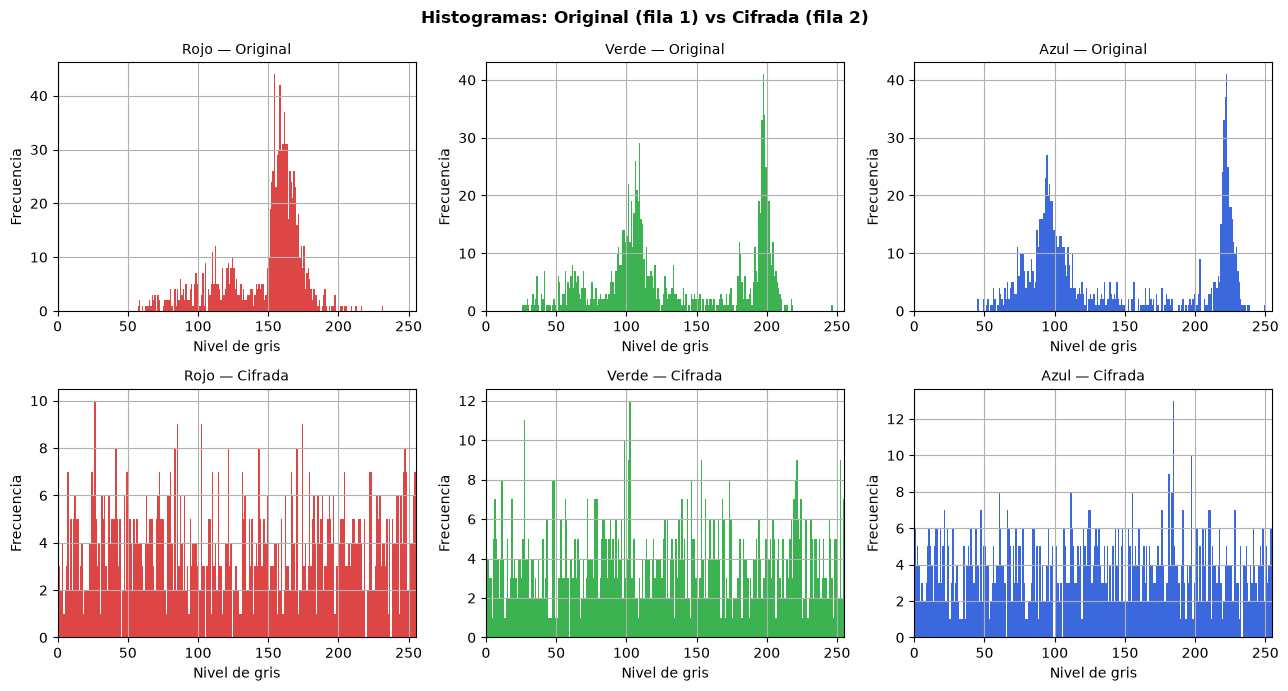


========== ENTROPÍA (bits) ==========
Canal        Original      Cifrada
----------------------------------
Rojo         6.310108     7.813733
Verde        6.781022     7.814798
Azul         6.682761     7.823341
----------------------------------

========== NPCR y UACI (Original vs Cifrada) ==========
Canal      NPCR (%)   UACI (%)
------------------------------
Rojo        99.4141    27.5586
Verde       99.3164    29.6998
Azul        99.7070    31.0451
------------------------------
  Referencia ideal: NPCR ≈ 99.6094%  |  UACI ≈ 33.4635%


========== TABLA DE CORRELACIONES ==========
Canal    Imagen          Horiz       Vert       Diag
----------------------------------------------------
Rojo     Original     0.767967   0.666974   0.630659
Rojo     Cifrada      0.076486  -0.030496   0.006707
----------------------------------------------------
Verde    Original     0.861945   0.815049   0.756439
Verde    Cifrada     -0.002750  -0.010189   0.005124
----------------------------------

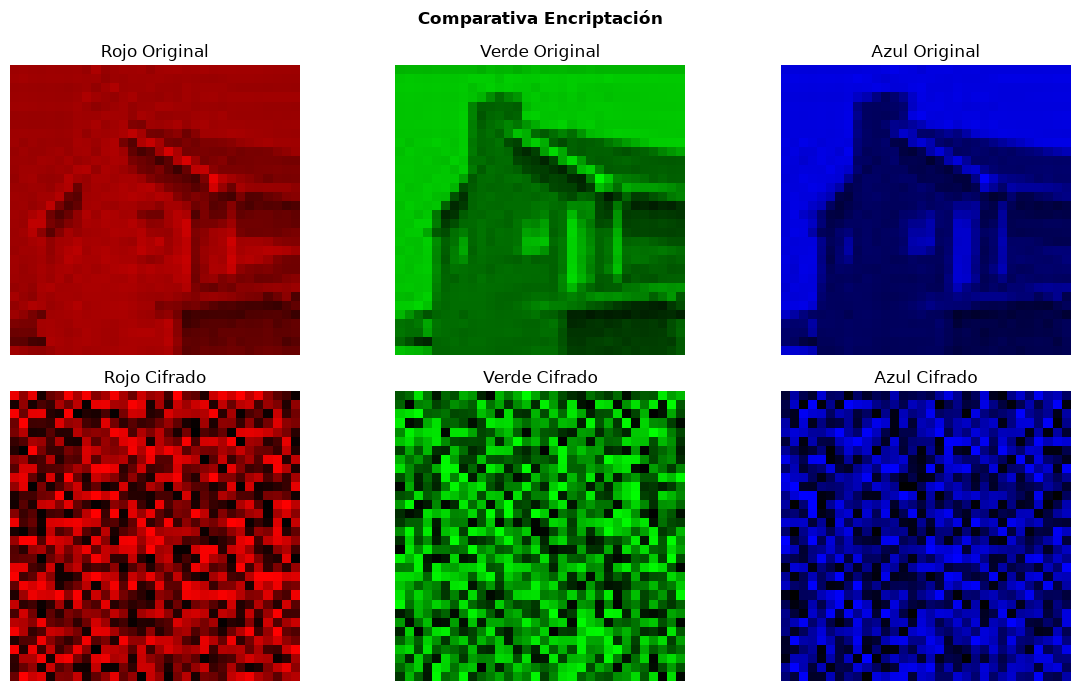

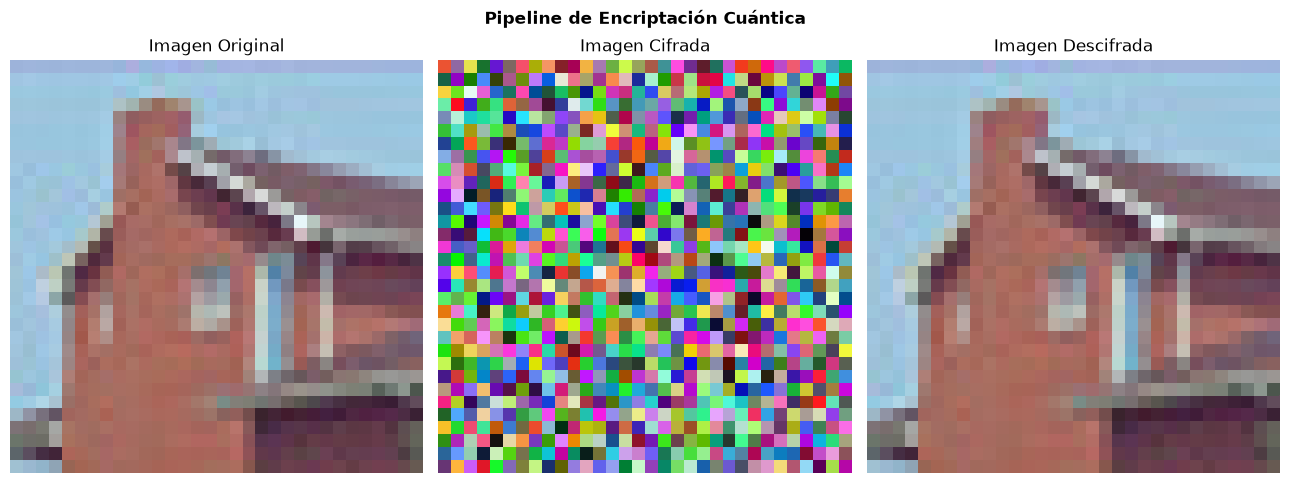

✓ Validación: Imágenes 100% idénticas. Diferencia = 0.


In [19]:
analisis_seguridad(enc, img_dec)

### Prueba de sensibilidad de clave

In [ ]:
prueba_sensibilidad_clave(enc)

### Resumen final

In [ ]:
print(f"\n  Tiempo total: {enc['tiempo_enc']:.2f} s (encriptación)")
print("  Figuras guardadas: histogramas.png, comparativa_canales.png,")
print("                     resultado_final.png, sensibilidad_clave.png")